In [107]:
epochs = 20
batch_size = 64
lr = 0.1
drop_prob = 0.5
lambda_reg = 0.001

train_acc_history = []
test_acc_history = []

for epoch in range(epochs):
    # Shuffle
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        z1, a1, z2, a2, mask = forward(X_batch, W1, b1, W2, b2, drop_prob, train=True)
        W1, b1, W2, b2 = backward(X_batch, y_batch, z1, a1, a2, W1, W2, mask, lr, lambda_reg)
    
    # Compute accuracies
    _, _, _, train_pred, _ = forward(X_train, W1, b1, W2, b2, drop_prob=0.0, train=False)
    _, _, _, test_pred, _ = forward(X_test, W1, b1, W2, b2, drop_prob=0.0, train=False)
    
    train_acc = accuracy(y_train, train_pred)
    test_acc = accuracy(y_test, test_pred)
    
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

TypeError: matrix.sum() got an unexpected keyword argument 'keepdims'

In [106]:
def backward(X, y, z1, a1, a2, W1, W2, mask=None, lr=0.01, lambda_reg=0.001):
    m = X.shape[0]
    
    dz2 = a2 - y
    dW2 = (a1.T @ dz2) / m + lambda_reg * W2
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    
    da1 = dz2 @ W2.T
    if mask is not None:
        da1 *= mask
    dz1 = da1 * relu_derivative(z1)
    
    dW1 = (X.T @ dz1) / m + lambda_reg * W1
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    
    # Return updated weights, don't try to modify global variables inside
    W1_new = W1 - lr * dW1
    b1_new = b1 - lr * db1
    W2_new = W2 - lr * dW2
    b2_new = b2 - lr * db2
    
    return W1_new, b1_new, W2_new, b2_new  

In [108]:
# -----------------------------
# 1️⃣ Load MNIST and force ndarray
# -----------------------------
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = np.array(mnist['data'])      # force ndarray
y = np.array(mnist['target'].astype(int))

# Normalize inputs
X = X / 255.0

# One-hot encode labels
encoder = OneHotEncoder()
y_onehot = np.array(encoder.fit_transform(y.reshape(-1, 1)))  # force ndarray

# Train-test split
X_train, X_test, y_train, y_test = map(np.array, train_test_split(X, y_onehot, test_size=0.2, random_state=42))

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

Epoch 1/20 - Train Acc: 0.9200, Test Acc: 0.9176
Epoch 2/20 - Train Acc: 0.9387, Test Acc: 0.9361
Epoch 3/20 - Train Acc: 0.9511, Test Acc: 0.9456
Epoch 4/20 - Train Acc: 0.9570, Test Acc: 0.9530
Epoch 5/20 - Train Acc: 0.9610, Test Acc: 0.9551
Epoch 6/20 - Train Acc: 0.9621, Test Acc: 0.9566
Epoch 7/20 - Train Acc: 0.9661, Test Acc: 0.9591
Epoch 8/20 - Train Acc: 0.9677, Test Acc: 0.9600
Epoch 9/20 - Train Acc: 0.9684, Test Acc: 0.9606
Epoch 10/20 - Train Acc: 0.9701, Test Acc: 0.9634
Epoch 11/20 - Train Acc: 0.9709, Test Acc: 0.9642
Epoch 12/20 - Train Acc: 0.9719, Test Acc: 0.9652
Epoch 13/20 - Train Acc: 0.9730, Test Acc: 0.9652
Epoch 14/20 - Train Acc: 0.9726, Test Acc: 0.9654
Epoch 15/20 - Train Acc: 0.9746, Test Acc: 0.9666
Epoch 16/20 - Train Acc: 0.9744, Test Acc: 0.9659
Epoch 17/20 - Train Acc: 0.9747, Test Acc: 0.9669
Epoch 18/20 - Train Acc: 0.9762, Test Acc: 0.9677
Epoch 19/20 - Train Acc: 0.9757, Test Acc: 0.9672
Epoch 20/20 - Train Acc: 0.9767, Test Acc: 0.9691


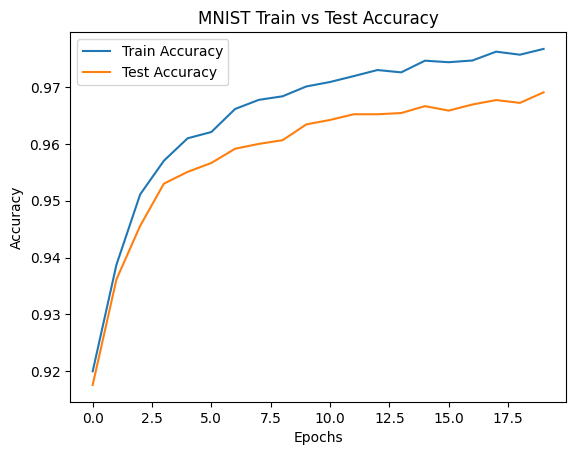

In [113]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)

# One-hot encode labels (dense array)
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# -----------------------------
# 2️⃣ Hyperparameters
# -----------------------------
input_dim = X_train.shape[1]  # 784
hidden_dim = 128
output_dim = 10
lr = 0.1
epochs = 20
batch_size = 64
drop_prob = 0.5
lambda_reg = 0.001

# -----------------------------
# 3️⃣ Initialize weights
# -----------------------------
np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))

# -----------------------------
# 4️⃣ Helper functions
# -----------------------------
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

# -----------------------------
# 5️⃣ Forward pass with dropout
# -----------------------------
def forward(X, W1, b1, W2, b2, drop_prob=0.0, train=True):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    mask = None
    if train and drop_prob > 0.0:
        mask = (np.random.rand(*a1.shape) > drop_prob) / (1 - drop_prob)
        a1 *= mask
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2, mask

# -----------------------------
# 6️⃣ Backward pass with L2
# -----------------------------
def backward(X, y, z1, a1, a2, W1, W2, b1, b2, mask=None, lr=0.01, lambda_reg=0.001):
    m = X.shape[0]
    dz2 = a2 - y
    dW2 = (a1.T @ dz2) / m + lambda_reg * W2
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    da1 = dz2 @ W2.T
    if mask is not None:
        da1 *= mask
    dz1 = da1 * relu_derivative(z1)
    dW1 = (X.T @ dz1) / m + lambda_reg * W1
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    W1_new = W1 - lr * dW1
    b1_new = b1 - lr * db1
    W2_new = W2 - lr * dW2
    b2_new = b2 - lr * db2
    return W1_new, b1_new, W2_new, b2_new

# -----------------------------
# 7️⃣ Training loop
# -----------------------------
train_acc_history, test_acc_history = [], []

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        z1, a1, z2, a2, mask = forward(X_batch, W1, b1, W2, b2, drop_prob, train=True)
        W1, b1, W2, b2 = backward(X_batch, y_batch, z1, a1, a2, W1, W2, b1, b2, mask, lr, lambda_reg)
    
    # Compute accuracies on full datasets
    _, _, _, train_pred, _ = forward(X_train, W1, b1, W2, b2, drop_prob=0.0, train=False)
    _, _, _, test_pred, _ = forward(X_test, W1, b1, W2, b2, drop_prob=0.0, train=False)
    train_acc = accuracy(y_train, train_pred)
    test_acc = accuracy(y_test, test_pred)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# -----------------------------
# 8️⃣ Plot accuracy
# -----------------------------
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(test_acc_history, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MNIST Train vs Test Accuracy')
plt.legend()
plt.show()